## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import reprojection_consistency_score
import h5py
import numpy as np
from skimage.transform import pyramid_gaussian
from scipy.ndimage import zoom

def tomo_data(file,redo_align=False):
    try:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    except KeyError:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    angles = angles * np.pi / 180
    return projs, angles


## Import real Data

In [2]:
import os

downsample = 4
filename = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
cached_filename = filename.replace(".hdf5", f"_ds{downsample}.hdf5")

if os.path.exists(cached_filename):
    print(f"Loading downsampled cache: {cached_filename}")
    projections, angles = tomo_data(cached_filename)
    print(projections.shape)
    tomo = tomoData(projections, angles)
else:
    print("Cache not found — loading full dataset...")
    projections_og, angles = tomo_data(filename, redo_align=True)
    print("Full dataset shape:", projections_og.shape)
    _needs_downsample = True

num_angles = projections.shape[0] if os.path.exists(cached_filename) else projections_og.shape[0]

if not os.path.exists(cached_filename):
    print("Downsampling...")
    projections = zoom(projections_og, (1, 1/downsample, 1/downsample), order=1)
    print(projections.shape)

    print(f"Saving downsampled cache to: {cached_filename}")
    with h5py.File(cached_filename, 'w') as hf:
        hf.create_dataset('data', data=projections)
        hf.create_dataset('angles', data=angles * 180 / np.pi)  # save back in degrees

    tomo = tomoData(projections, angles)

Loading downsampled cache: /Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2_ds4.hdf5
(558, 146, 452)


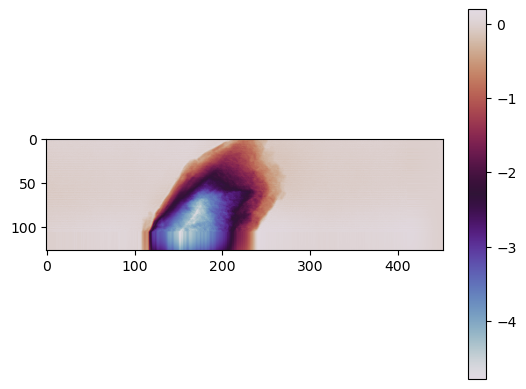

In [3]:
from helperFunctions import subpixel_shift
imageToShift = tomo.workingProjections[0,20:,::]
shiftedImage = subpixel_shift(imageToShift, shift_y=-20, shift_x=-40)

import matplotlib.pyplot as plt
plt.imshow(shiftedImage, cmap='twilight')
plt.colorbar()
plt.show()

In [4]:
print(projections.shape)
tomo.makeNotebookProjMovie()

(558, 146, 452)


Output()

## Align Data

In [5]:
# # Show bad reconstruction prior to alignment
# tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
# tomo.normalize(isPhaseData=True)

# tomo.reconstruct(algorithm='art')
# print("\nBad reconstruction prior to alignment")
# badRecon = tomo.recon.copy()
# MoviePlotter(badRecon)# 

In [6]:
# # Reprojection Consistency Score — before alignment
# rcs_before, _, _ = tomo.reprojection_consistency_score(plot=True)

# #Sinogram consistency score — before alignment
# scs_before, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

In [7]:
#Initialize and do bulk move
tomo.reset_workingProjections(x_size=None, y_size=None)
tomo.normalize(isPhaseData=True)

tomo.cross_correlate_align(
    tolerance=0.001,
    maxShiftTolerance=0.5,
    max_iterations=15,
    stepRatio=0.8,        # "sr08" — the key differentiator vs default
    downsample=4,
    use_grad=True,        # "grad" variant
    yROI_Range=None,
    xROI_Range=None,
    isFull360=False,
)
tomo.make_updates_shift()
tomo.makeNotebookProjMovie(show_trust_region=True)



Normalizing projections


Cross-Correlation Alignment  [4x downsample | full frame | gradient mode]


Iteration 1/15: 100%|██████████| 557/557 [00:02<00:00, 235.04it/s]


Iteration 1: avg shift = 16.6323 px, max shift = 83.2301 px


Iteration 2/15: 100%|██████████| 557/557 [00:02<00:00, 277.19it/s]


Iteration 2: avg shift = 3.3089 px, max shift = 16.4831 px


...

Iteration 15/15: 100%|██████████| 557/557 [00:02<00:00, 225.18it/s]


Iteration 15: avg shift = 0.0353 px, max shift = 2.5298 px
Maximum iterations reached without convergence.


Apply shifts to final projections: 100%|██████████| 558/558 [00:05<00:00, 97.23it/s] 


Largest shifts per direction:
  Top    (down  37.28 px) — projection 434
  Bottom (up    19.68 px) — projection 461
  Left   (right 68.00 px) — projection 406
  Right  (left  105.12 px) — projection 266


Output()

In [8]:

#Then crop for speed and continue alignment
tomo.crop_center(new_x= tomo.workingProjections.shape[2]-(500//downsample), new_y = tomo.workingProjections.shape[1])
# ── Step 2: XCA pass 2 — gradient-based, medium resolution
tomo.cross_correlate_align(
    tolerance=0.001,
    maxShiftTolerance=0.5,
    max_iterations=15,
    stepRatio=0.8,
    downsample=2,
    use_grad=True,
    yROI_Range=None,
    xROI_Range=None,
    isFull360=False,
)

# ── Step 3: XCA pass 3 — gradient-based, full resolution
tomo.cross_correlate_align(
    tolerance=0.001,
    maxShiftTolerance=0.5,
    max_iterations=15,
    stepRatio=0.8,
    downsample=1,
    use_grad=True,
    yROI_Range=None,
    xROI_Range=None,
    isFull360=False,
)

# ── Step 4: PMA — 2-level pyramid, scale=4, [5, 5] iters, sigma=2.0
# Config 23: pma_2lev_sr09_sig2 → levels=2, scale=4, iters_per_level=[5, 5], of_sigma=2.0
tomo.PMA(
    levels=2,
    scale=4,                        # 4x downsample per level → runs at 4x then 1x
    iterations_per_level=[5, 5],    # coarse level first, then fine
    tolerance=0.01,
    algorithm='art',
    standardize=False,
)
tomo.make_updates_shift()
tomo.makeNotebookProjMovie(show_trust_region=True)



Cross-Correlation Alignment  [2x downsample | full frame | gradient mode]


Iteration 1/15: 100%|██████████| 557/557 [00:04<00:00, 138.45it/s]


Iteration 1: avg shift = 0.2856 px, max shift = 14.7135 px


Iteration 2/15: 100%|██████████| 557/557 [00:03<00:00, 170.74it/s]


Iteration 2: avg shift = 0.0965 px, max shift = 6.3985 px


...

  Iter 5: avg=0.0332 px



PMA complete.


Apply shifts to final projections: 100%|██████████| 558/558 [00:05<00:00, 108.18it/s]


Largest shifts per direction:
  Top    (down  37.28 px) — projection 434
  Bottom (up    19.68 px) — projection 461
  Left   (right 21.75 px) — projection 556
  Right  (left  43.12 px) — projection 266


Output()

In [9]:
tomo.makeNotebookProjMovie()
tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

Output()



Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Good Reconstruction after alignment


Output()

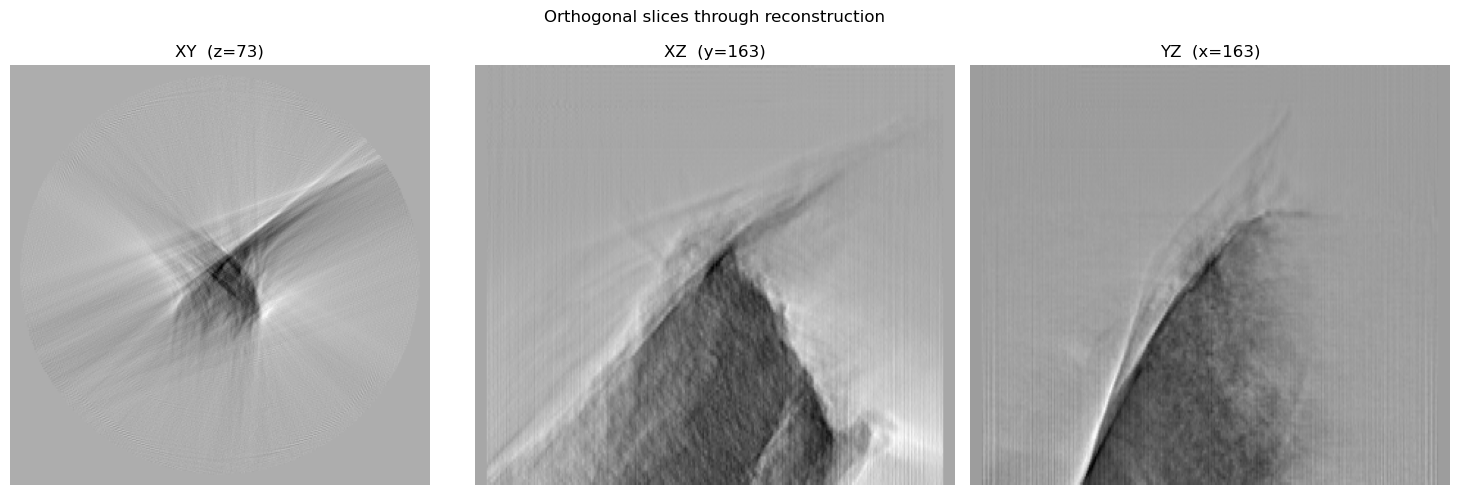

In [10]:
tomo.displayReconOrthogonalSlices()



Computing reprojections of reconstruction...
Computing per-angle NRMSE...


NRMSE per angle: 100%|██████████| 558/558 [00:00<00:00, 2459.17it/s]



─── Reprojection Consistency Score ───────────────────────
  RCS (mean NRMSE):   0.5284
  Best  angle [ 548]:  NRMSE = 0.0962
  Worst angle [ 242]:  NRMSE = 1.1149
  Std across angles:  0.1682
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────



/Users/levihancock/Documents/Work/Code/TomoMono/alignment_methods.py:1188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


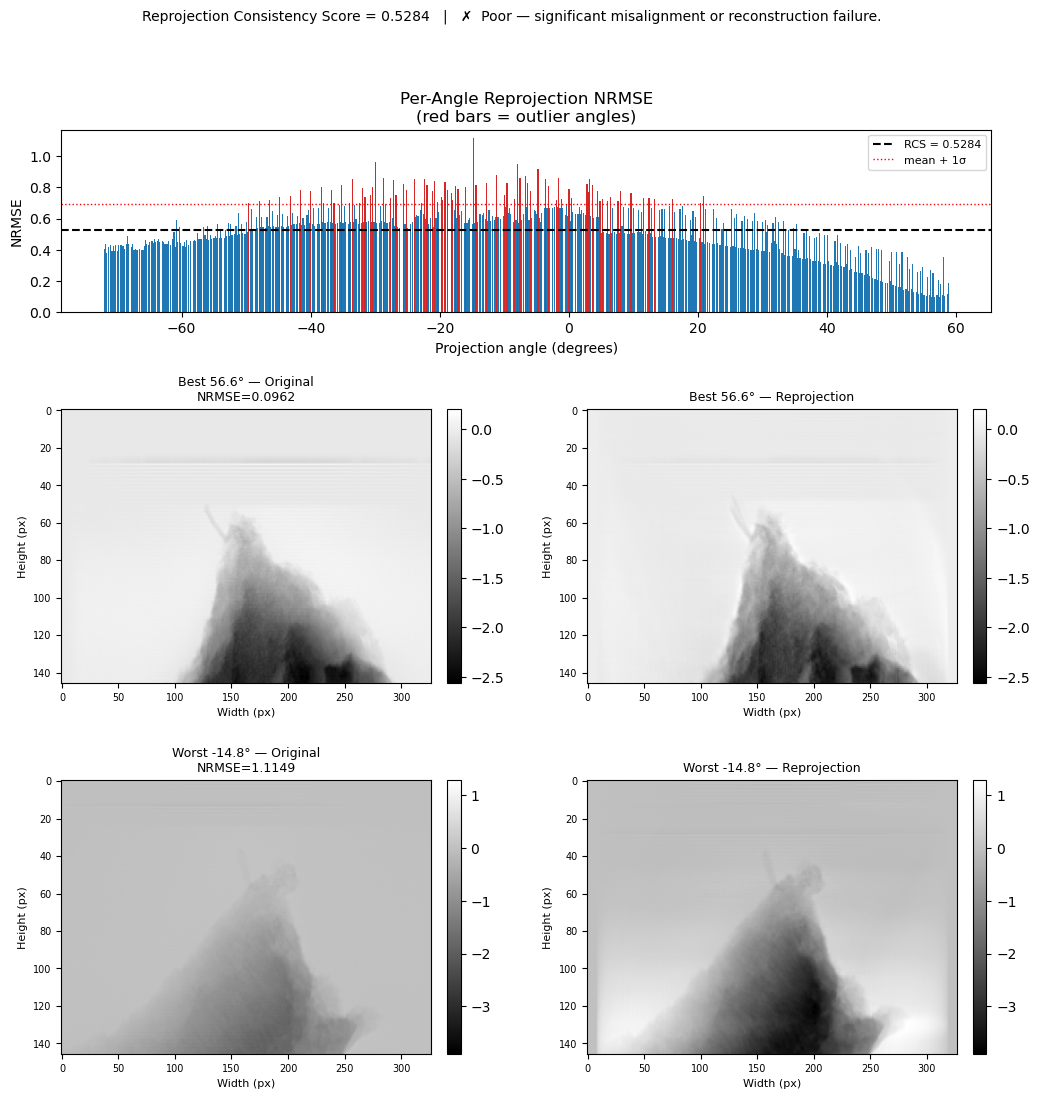



Sinogram consistency:
  x_cm (horizontal) — RMSE: 1.9695 px  |  R²: 0.866188
  y_cm (vertical)   — RMSE: 5.3300 px  |  R²: 0.000000
  Combined RMSE:       4.0179 px


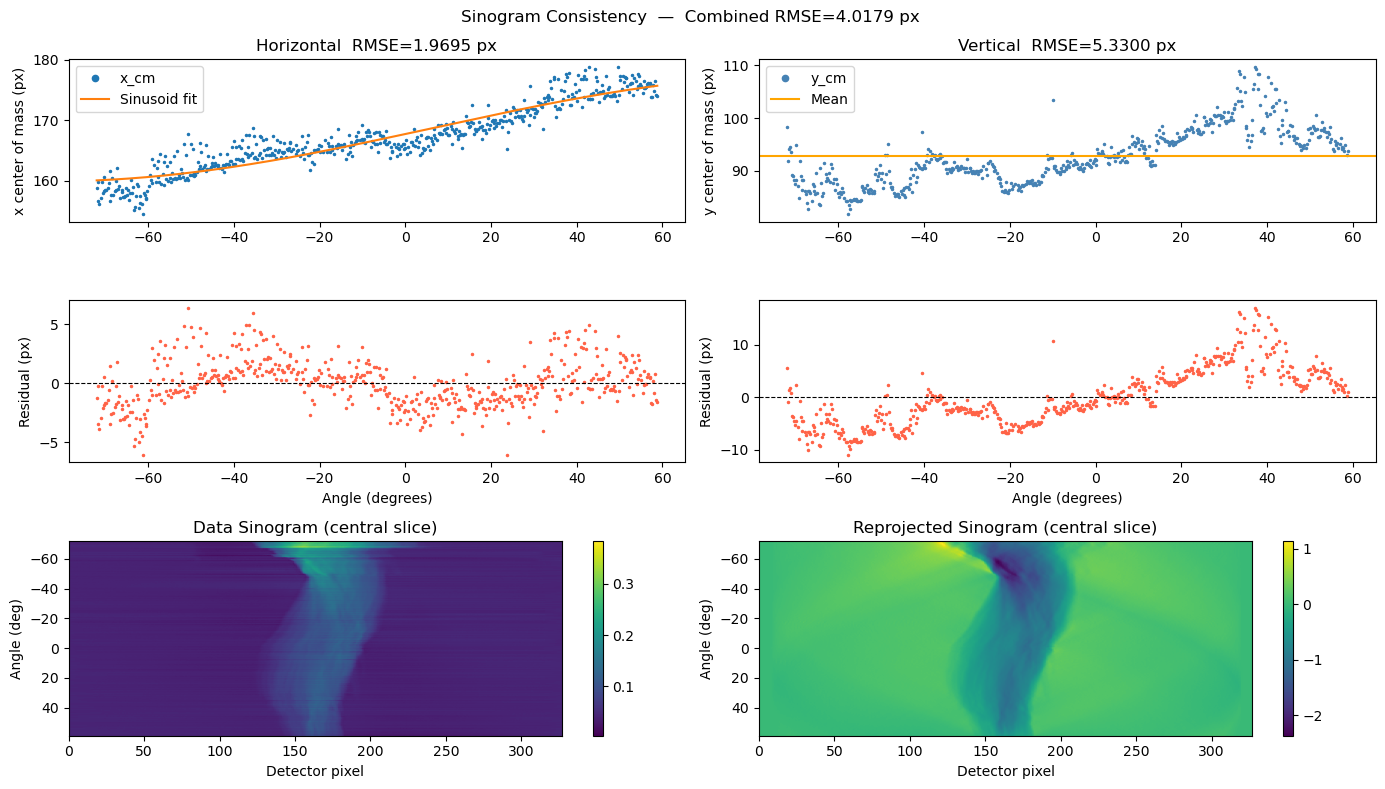

In [11]:
# Reprojection Consistency Score — after alignment
rcs_after, _, _ = tomo.reprojection_consistency_score(plot=True)

#Sinogram consistency score — after alignment
scs_after, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

# # print("=" * 52)
# # print("  ALIGNMENT QUALITY SUMMARY")
# # print("=" * 52)
# # print(f"  {'Metric':<22} {'Before':>8} {'After':>8} {'Δ':>10}")
# # print(f"  {'-'*50}")
# # print(f"  {'RCS (lower = better)':<22} {rcs_before:>8.4f} {rcs_after:>8.4f} {rcs_before - rcs_after:>+10.4f}")
# # print("=" * 52)

In [12]:
# import tifffile
# tifffile.imwrite("reconstruction(downsampled).tiff", tomo.recon.astype("float32"))

In [13]:
# reprojections = tomopy.project(
#     tomo.recon, tomo.ang, center=tomo.rotation_center,
#     emission=True, pad=False, ncore=None,
# )

# MoviePlotter(reprojections)